# Neural Networks

In [1]:
%load_ext IPython.extensions.autoreload
%autoreload 2

In [15]:
import sys,os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

In [16]:
import numpy as np
from src.data_reader import DataSource, read_vertices_VTK, num_vertices_VTK
from src.descriptors.dscs_driver import compute_descriptors

from src.utils import get_free_id, write_jsonl, clear_jsonl

!pip install numpy==1.23.0

In [17]:
from ripser import ripser
from persim import plot_diagrams

In [18]:
from gudhi import RipsComplex, AlphaComplex, plot_persistence_diagram
from gudhi.representations import ProminentPoints
from gudhi.representations import PersistenceImage

In [19]:
from sklearn.decomposition import PCA, KernelPCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.mixture import GaussianMixture as GMM
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import AdaBoostClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, precision_recall_curve

import joblib

In [20]:
import csv

In [43]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchinfo import summary as torch_summary

from IPython.display import display, clear_output

from src.learning.nn import SimpleNN, train, predict, Autoencoder

### Reload descriptors

In [72]:
# load descriptors

Model='quantiles'
Model='AlphaProminent'

# data base path
data_base = './data/data/'

save_descs_path = os.path.join(data_base,'saved_descriptors/train_set/')

data = np.load(os.path.join(save_descs_path,Model+'Data.npy'))
labels = np.load(os.path.join(save_descs_path,Model+'Labels.npy'))

data = np.load('ThisData.npy')

print(data.shape, labels.shape)

(9244, 96) (9244,)


## Normalization

In [38]:
SSc = StandardScaler()
data = SSc.fit_transform(data)
data.shape

(9244, 75)

# Cross-Validation

In [55]:
StrShSp = StratifiedShuffleSplit(n_splits=15, train_size=0.8, random_state=42)

# get indices of split
train_idx, val_idx = next(StrShSp.split(data, labels))

train_data = data[train_idx,:]
train_labels = labels[train_idx]

val_data = data[val_idx]
val_labels = labels[val_idx]

# log file for run
run_log = './runs/trainings/runs.jsonl'
# get a new run id
run_id = get_free_id(run_log)


In [56]:
train_idx.shape

(59161,)

In [14]:
counts, bins = np.histogram(train_labels, bins=100)
plt.bar(bins[:-1],counts)

NameError: name 'plt' is not defined

<BarContainer object of 100 artists>

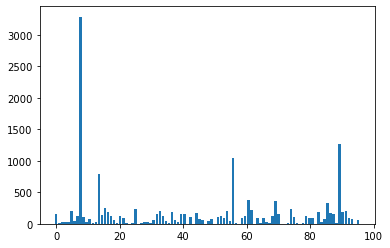

In [22]:
counts, bins = np.histogram(val_labels, bins=100)
plt.bar(bins[:-1],counts)

In [23]:
_, counts = np.unique(labels,return_counts=True)
np.sort(counts)

array([   16,    16,    16,    16,    16,    16,    16,    16,    16,
          16,    24,    24,    24,    24,    40,    40,    48,    56,
          64,    72,    80,    80,    80,    80,    80,   112,   112,
         120,   136,   136,   144,   144,   152,   168,   176,   184,
         200,   208,   216,   264,   272,   280,   296,   336,   344,
         352,   392,   392,   416,   424,   432,   432,   456,   456,
         464,   464,   488,   528,   552,   560,   568,   584,   584,
         592,   600,   608,   608,   624,   640,   712,   744,   760,
         760,   776,   808,   816,   824,   872,   920,   928,   944,
         952,  1008,  1016,  1024,  1032,  1080,  1144,  1200,  1232,
        1624,  1784,  1920,  3912,  5232,  6304, 16432])

In [57]:
np.unique(val_labels).shape

(97,)

# Classifier

### NN

In [58]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print('Device = ',device)

X_train = torch.tensor(train_data, dtype=torch.float32)
y_train = torch.tensor(train_labels, dtype=torch.long)

X_val = torch.tensor(val_data, dtype=torch.float32)
y_val = torch.tensor(val_labels, dtype=torch.long)

#WX_val = torch.tensor(data, dtype=torch.float32)
#Wy_val = torch.tensor(labels, dtype=torch.long)



# data loader
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=128, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=128)
whole_data = DataLoader(TensorDataset(WX_val, Wy_val), batch_size=128)

Device =  cuda


In [59]:
# Model, Loss, and Optimizer

m = train_data.shape[1]
c = np.unique(labels).shape[0]

# Model save path
trained_model_path = './trained_models/nn/best_weights.pth'

model = SimpleNN(m, c)

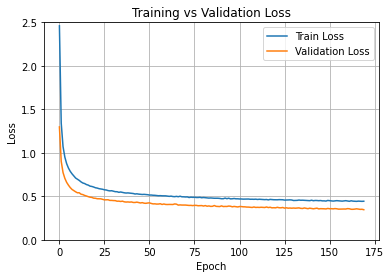

KeyboardInterrupt: 

In [60]:
summary = torch_summary(model,None)

try: 
    pass
    #model.load_state_dict(torch.load(trained_model_path))
except:
    pass
criterion = nn.CrossEntropyLoss()  # Cross-entropy loss
optimizer = optim.Adam(model.parameters(), lr=4e-4, weight_decay=1e-4)  # Adam optimizer

epochs = 2000
# Early Stopping Parameters
patience = int(epochs/10)  # Stop if no improvement for 'patience' epochs

params = {'id':run_id , 'model':str(type(model).__name__) , 'epochs':epochs , 'patience':patience , \
          'optimizer':str(type(optimizer).__name__) , 'loss':str(type(criterion).__name__) , \
         'model_summary':[str(summary)]}


train(epochs, model, criterion, optimizer, train_loader, val_loader, trained_model_path, patience)

#### Good values!

we get a good training with dropout 25%, input to 50, 50 to 50, 50 to output
with learning rate 5 10-5 and decay 1e-4

In [24]:
model = SimpleNN(m, c)
model.load_state_dict(torch.load(trained_model_path))
model.to(device)
model.eval()

pred_labels = predict(model, val_loader, device)

In [48]:
model.to(device)
model.eval()

pred_labels = predict(model, val_loader, device)
#pred_labels = predict(model, whole_data, device)

# Scoring

In [49]:
acc = accuracy_score(val_labels, pred_labels)
#acc = accuracy_score(labels, pred_labels)

#params.update( {'accuracy':acc} )
#write_jsonl(run_log, params)
print(acc)

0.9083902373064702


In [51]:
print(classification_report(val_labels, pred_labels, zero_division=0.0))
#print(classification_report(labels, pred_labels, zero_division=0.0))

              precision    recall  f1-score   support

           0       0.98      0.99      0.98       162
           1       1.00      1.00      1.00         5
           2       1.00      1.00      1.00        27
           3       1.00      1.00      1.00        34
           4       1.00      0.25      0.40        24
           5       1.00      1.00      1.00       203
           6       1.00      0.95      0.97        40
           7       0.99      0.97      0.98       120
           8       1.00      0.99      1.00      3287
           9       0.91      0.99      0.95       106
          10       1.00      0.95      0.98        22
          11       0.97      1.00      0.99        69
          12       1.00      0.75      0.86        16
          13       1.00      1.00      1.00        35
          14       0.68      0.88      0.77       783
          15       0.96      1.00      0.98       142
          16       0.97      0.98      0.97       247
          17       0.91    

In [52]:
np.unique(pred_labels).shape

(95,)

In [41]:
np.unique(val_labels).shape

(97,)

In [53]:
cm = confusion_matrix(val_labels, pred_labels, normalize='pred')

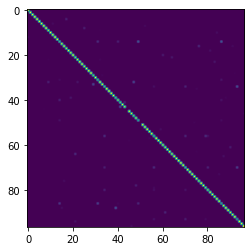

In [54]:
plt.imshow(cm)


In [73]:
cm[32, 47]

0.17391304347826086

### Make model persistent

In [87]:
absname, ext = os.path.splitext(trained_model_path)
name = absname + str(run_id) + ext
modelname = absname + str(run_id) + 'Model' + ext
torch.save(model.state_dict(), name)
torch.save(model, modelname)


In [91]:
mod = torch.load(modelname, weights_only=False)

# Autoencoder

In [49]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print('Device = ',device)

X_train = torch.tensor(train_data, dtype=torch.float32)
#y_train = torch.tensor(train_labels, dtype=torch.long)

X_val = torch.tensor(val_data, dtype=torch.float32)
#y_val = torch.tensor(val_labels, dtype=torch.long)

# data loader
train_loader = DataLoader(TensorDataset(X_train, X_train), batch_size=50, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, X_val), batch_size=50)

Device =  cuda


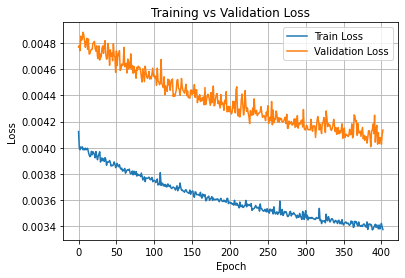

KeyboardInterrupt: 

In [54]:
# Model, Loss, and Optimizer

p = train_data.shape[1]

# Model save path
trained_model_path = './trained_models/nn/Autoencoder_best_weights.pth'

model = Autoencoder(p, noise = 0.0)

summary = torch_summary(model,None)

try: 
    pass
    model.load_state_dict(torch.load(trained_model_path))
except:
    pass
criterion = nn.MSELoss()  # Cross-entropy loss
optimizer = optim.Adam(model.parameters(), lr=1e-4)  # Adam optimizer

epochs = 2000
# Early Stopping Parameters
patience = epochs  # Stop if no improvement for 'patience' epochs

params = {'id':run_id , 'model':str(type(model).__name__) , 'epochs':epochs , 'patience':patience , \
          'optimizer':str(type(optimizer).__name__) , 'loss':str(type(criterion).__name__) , \
         'model_summary':[str(summary)]}


train(epochs, model, criterion, optimizer, train_loader, val_loader, trained_model_path, patience)

In [100]:
modelAE = Autoencoder(75, noise = 0.0)

In [104]:
modelAE = joblib.load( './trained_models/nn/Autoencoder_best_weights12.pkl' )

### Write model

In [57]:
model_path_filename, extension = os.path.splitext(trained_model_path)
joblib.dump(model , model_path_filename + str(run_id) +'.pkl');

### Score

In [63]:
losses = []

for i in range(val_data.shape[0]):
    X = val_data[ i , :]
    X = torch.tensor(X, dtype=torch.float32)
    output = model.forward( X )
    loss = criterion( output , X ).detach().numpy()

    losses.append(loss)

print(np.mean( np.array(losses, dtype=float) ))



0.0033910545772518268


0.043826126


## Use encoder

In [68]:
encoded_data = np.zeros( ( data.shape[0] , 15 ) )

for i in range(data.shape[0]):

    X = data[ i , :]
    X = torch.tensor(X, dtype=torch.float32)
    
    compressed = model.encode(X).detach().numpy()
    encoded_data[ i , : ] = compressed
    

In [69]:
encoded_data.shape

(9244, 15)

### Save data

In [99]:
np.save( './data/data/saved_descriptors/train_set/EncodedAlphaProminent.npy', encoded_data)

# Augmented Data

In [8]:
dataEncAlpha_aug = np.load('./data/data/saved_descriptors/train_set/EncodedAlphaProminent_aug.npy')
dataS_aug = np.load('./data/sectors/saved_descriptors/train_set/AugmentedData.npy')
labels = np.load('./data/sectors/saved_descriptors/train_set/AugmentedLabels.npy')

In [9]:
data = np.concatenate( [dataS_aug , dataEncAlpha_aug] , axis = 1 )

111